**Poblem Statement:**

Online learning platforms have grown rapidly, but many students who enroll in courses do not complete them. This leads to high dropout rates and reduces the effectiveness of online education systems

The goal of this project is to build a predictive machine learning model that analyzes student engagement metrics and academic performance indicatorsto determine the likelihood of course completion in an online learning environment.

Import Required libraries:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [ ]:
from sklearn.metrics import accuracy_score,classification_report
from sklearn.preprocessing import OrdinalEncoder,StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

Data loading:

In [ ]:
df=pd.read_csv(r"/content/drive/MyDrive/student_Ml_project/Studen_Course_Prediction.zip")
df.head()

,Student_ID,Name,Gender,Age,Education_Level,Employment_Status,City,Device_Type,Internet_Connection_Quality,Course_ID,...,Enrollment_Date,Payment_Mode,Fee_Paid,Discount_Used,Payment_Amount,App_Usage_Percentage,Reminder_Emails_Clicked,Support_Tickets_Raised,Satisfaction_Rating,Completed
0,STU100000,Vihaan Patel,Male,19,Diploma,Student,Indore,Laptop,Medium,C102,...,01-06-2024,Scholarship,No,No,1740,49,3,4,3.5,Completed
1,STU100001,Arjun Nair,Female,17,Bachelor,Student,Delhi,Laptop,Low,C106,...,27-04-2025,Credit Card,Yes,No,6147,86,0,0,4.5,Not Completed
2,STU100002,Aditya Bhardwaj,Female,34,Master,Student,Chennai,Mobile,Medium,C101,...,20-01-2024,NetBanking,Yes,No,4280,85,1,0,5.0,Completed
3,STU100003,Krishna Singh,Female,29,Diploma,Employed,Surat,Mobile,High,C105,...,13-05-2025,UPI,Yes,No,3812,42,2,3,3.8,Completed
4,STU100004,Krishna Nair,Female,19,Master,Self-Employed,Lucknow,Laptop,Medium,C106,...,19-12-2024,Debit Card,Yes,Yes,5486,91,3,0,4.0,Completed


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 40 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Student_ID                    100000 non-null  object 
 1   Name                          100000 non-null  object 
 2   Gender                        100000 non-null  object 
 3   Age                           100000 non-null  int64  
 4   Education_Level               100000 non-null  object 
 5   Employment_Status             100000 non-null  object 
 6   City                          100000 non-null  object 
 7   Device_Type                   100000 non-null  object 
 8   Internet_Connection_Quality   100000 non-null  object 
 9   Course_ID                     100000 non-null  object 
 10  Course_Name                   100000 non-null  object 
 11  Category                      100000 non-null  object 
 12  Course_Level                  100000 non-null

In [ ]:
columns_to_keep = [col for col in df.columns if col not in ['Student_ID', 'Name']]
df = df[columns_to_keep]
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 38 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Gender                        100000 non-null  object 
 1   Age                           100000 non-null  int64  
 2   Education_Level               100000 non-null  object 
 3   Employment_Status             100000 non-null  object 
 4   City                          100000 non-null  object 
 5   Device_Type                   100000 non-null  object 
 6   Internet_Connection_Quality   100000 non-null  object 
 7   Course_ID                     100000 non-null  object 
 8   Course_Name                   100000 non-null  object 
 9   Category                      100000 non-null  object 
 10  Course_Level                  100000 non-null  object 
 11  Course_Duration_Days          100000 non-null  int64  
 12  Instructor_Rating             100000 non-null

,Gender,Age,Education_Level,Employment_Status,City,Device_Type,Internet_Connection_Quality,Course_ID,Course_Name,Category,...,Enrollment_Date,Payment_Mode,Fee_Paid,Discount_Used,Payment_Amount,App_Usage_Percentage,Reminder_Emails_Clicked,Support_Tickets_Raised,Satisfaction_Rating,Completed
0,Male,19,Diploma,Student,Indore,Laptop,Medium,C102,Data Analysis with Python,Programming,...,01-06-2024,Scholarship,No,No,1740,49,3,4,3.5,Completed
1,Female,17,Bachelor,Student,Delhi,Laptop,Low,C106,Machine Learning A-Z,Programming,...,27-04-2025,Credit Card,Yes,No,6147,86,0,0,4.5,Not Completed
2,Female,34,Master,Student,Chennai,Mobile,Medium,C101,Python Basics,Programming,...,20-01-2024,NetBanking,Yes,No,4280,85,1,0,5.0,Completed
3,Female,29,Diploma,Employed,Surat,Mobile,High,C105,UI/UX Design Fundamentals,Design,...,13-05-2025,UPI,Yes,No,3812,42,2,3,3.8,Completed
4,Female,19,Master,Self-Employed,Lucknow,Laptop,Medium,C106,Machine Learning A-Z,Programming,...,19-12-2024,Debit Card,Yes,Yes,5486,91,3,0,4.0,Completed


In [ ]:
#Removing Duplicates
df.duplicated().sum()

np.int64(0)

In [ ]:
cat=df.select_dtypes("object")
num=df.select_dtypes("number")

In [ ]:
num.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 24 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Age                           100000 non-null  int64  
 1   Course_Duration_Days          100000 non-null  int64  
 2   Instructor_Rating             100000 non-null  float64
 3   Login_Frequency               100000 non-null  int64  
 4   Average_Session_Duration_Min  100000 non-null  int64  
 5   Video_Completion_Rate         100000 non-null  float64
 6   Discussion_Participation      100000 non-null  int64  
 7   Time_Spent_Hours              100000 non-null  float64
 8   Days_Since_Last_Login         100000 non-null  int64  
 9   Notifications_Checked         100000 non-null  int64  
 10  Peer_Interaction_Score        100000 non-null  float64
 11  Assignments_Submitted         100000 non-null  int64  
 12  Assignments_Missed            100000 non-null

In [ ]:
cat

,Gender,Education_Level,Employment_Status,City,Device_Type,Internet_Connection_Quality,Course_ID,Course_Name,Category,Course_Level,Enrollment_Date,Payment_Mode,Fee_Paid,Discount_Used,Completed
0,Male,Diploma,Student,Indore,Laptop,Medium,C102,Data Analysis with Python,Programming,Intermediate,01-06-2024,Scholarship,No,No,Completed
1,Female,Bachelor,Student,Delhi,Laptop,Low,C106,Machine Learning A-Z,Programming,Advanced,27-04-2025,Credit Card,Yes,No,Not Completed
2,Female,Master,Student,Chennai,Mobile,Medium,C101,Python Basics,Programming,Beginner,20-01-2024,NetBanking,Yes,No,Completed
3,Female,Diploma,Employed,Surat,Mobile,High,C105,UI/UX Design Fundamentals,Design,Beginner,13-05-2025,UPI,Yes,No,Completed
4,Female,Master,Self-Employed,Lucknow,Laptop,Medium,C106,Machine Learning A-Z,Programming,Advanced,19-12-2024,Debit Card,Yes,Yes,Completed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,Female,Bachelor,Student,Hyderabad,Mobile,Medium,C104,Digital Marketing Essentials,Marketing,Beginner,12-07-2024,UPI,Yes,No,Completed
99996,Female,Bachelor,Self-Employed,Delhi,Mobile,High,C104,Digital Marketing Essentials,Marketing,Beginner,13-01-2024,UPI,Yes,No,Not Completed
99997,Male,Master,Employed,Ahmedabad,Laptop,Medium,C107,Statistics for Data Science,Math,Intermediate,14-08-2024,UPI,Yes,Yes,Not Completed
99998,Female,Bachelor,Student,Ahmedabad,Mobile,High,C104,Digital Marketing Essentials,Marketing,Beginner,21-06-2025,Credit Card,Yes,No,Not Completed


Checking relation with target variable


In [ ]:
df["target_encoded"] = df["Completed"].map({"Completed": 1, "Not Completed": 0})

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 39 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Gender                        100000 non-null  object 
 1   Age                           100000 non-null  int64  
 2   Education_Level               100000 non-null  object 
 3   Employment_Status             100000 non-null  object 
 4   City                          100000 non-null  object 
 5   Device_Type                   100000 non-null  object 
 6   Internet_Connection_Quality   100000 non-null  object 
 7   Course_ID                     100000 non-null  object 
 8   Course_Name                   100000 non-null  object 
 9   Category                      100000 non-null  object 
 10  Course_Level                  100000 non-null  object 
 11  Course_Duration_Days          100000 non-null  int64  
 12  Instructor_Rating             100000 non-null

Correlation

Correlation for Numerucal features

In [ ]:
corr = df.corr(numeric_only=True)

In [ ]:
corr[["target_encoded"]]

,target_encoded
Age,0.000299
Course_Duration_Days,0.001341
Instructor_Rating,-0.000233
Login_Frequency,0.043300
Average_Session_Duration_Min,0.037160
Video_Completion_Rate,0.175222
Discussion_Participation,0.027553
Time_Spent_Hours,0.090079
Days_Since_Last_Login,-0.044754
Notifications_Checked,0.030876


In [ ]:
target_corr=corr[["target_encoded"]].sort_values(by='target_encoded',ascending=False)
target_corr

,target_encoded
target_encoded,1.000000
Progress_Percentage,0.214026
Video_Completion_Rate,0.175222
Assignments_Submitted,0.144848
Time_Spent_Hours,0.090079
Quiz_Score_Avg,0.080957
Payment_Amount,0.079383
Login_Frequency,0.043300
Average_Session_Duration_Min,0.037160
Project_Grade,0.036940


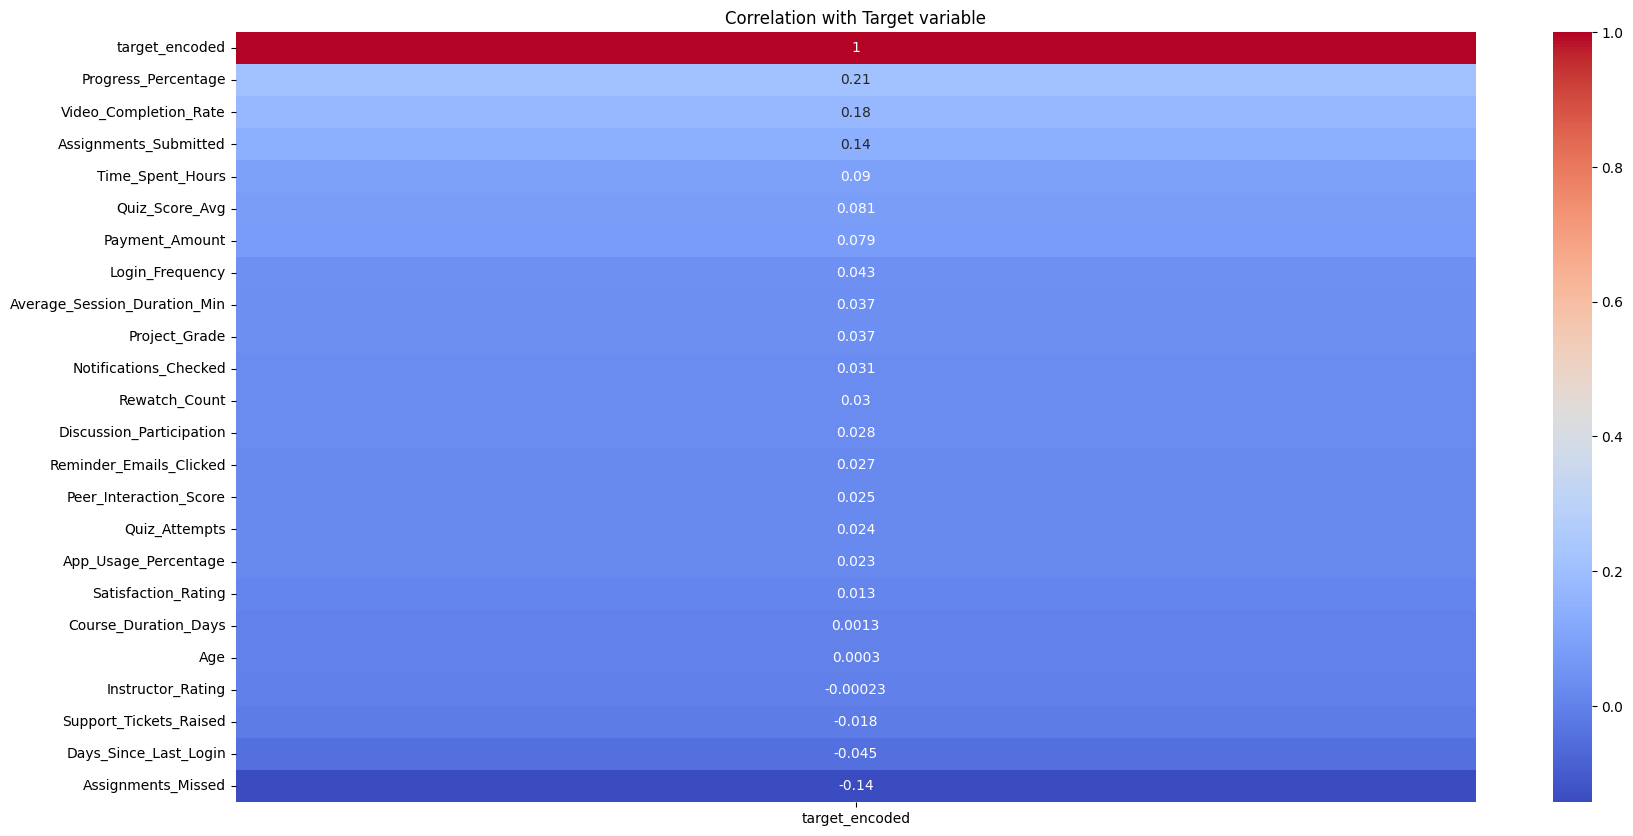

In [ ]:
plt.figure(figsize=(20,10))
sns.heatmap(target_corr, annot=True, cmap="coolwarm")
plt.title("Correlation with Target variable")
plt.show()

Check Relation for categorical data


In [ ]:
table=pd.crosstab(df['Education_Level'],df["target_encoded"])
from scipy.stats import chi2_contingency
chi2,p,dof,expected=chi2_contingency(table)
print("chi-square:",chi2)
print("p-value:",p)

chi-square: 12.77001242117069
p-value: 0.012455979956083113


In [ ]:
target=df["target_encoded"]

In [ ]:
from scipy.stats import chi2_contingency
results = []

for col in cat:

    contingency_table = pd.crosstab(df[col], target)

    chi2, p, dof, expected = chi2_contingency(contingency_table)

    results.append({
            "Feature": col,
            "Chi2": chi2,
            "p_value": p,
            "Significant": "Yes" if p < 0.05 else "No"
        })

chi_square_results = pd.DataFrame(results).sort_values("p_value")
chi_square_results

,Feature,Chi2,p_value,Significant
14,Completed,99995.998534,0.000000e+00,Yes
11,Payment_Mode,772.297672,1.137295e-164,Yes
12,Fee_Paid,721.401343,6.636518e-159,Yes
5,Internet_Connection_Quality,73.471419,1.111435e-16,Yes
2,Employment_Status,45.281058,8.063683e-10,Yes
4,Device_Type,10.454809,5.367437e-03,Yes
1,Education_Level,12.770012,1.245598e-02,Yes
0,Gender,6.737329,3.443560e-02,Yes
3,City,14.038107,4.468759e-01,No
10,Enrollment_Date,680.423564,8.519944e-01,No


selecting features which are highly co related with target variable

In [ ]:
y=df["target_encoded"]
X = df[
[
'Progress_Percentage',
'Video_Completion_Rate',
'Assignments_Submitted',
'Time_Spent_Hours',
'Quiz_Score_Avg',
'Payment_Amount',
'Payment_Mode',
'Fee_Paid',
'Internet_Connection_Quality',
'Employment_Status',
'Device_Type',
'Education_Level',
'Gender'
]
]



In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 13 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Progress_Percentage          100000 non-null  float64
 1   Video_Completion_Rate        100000 non-null  float64
 2   Assignments_Submitted        100000 non-null  int64  
 3   Time_Spent_Hours             100000 non-null  float64
 4   Quiz_Score_Avg               100000 non-null  float64
 5   Payment_Amount               100000 non-null  int64  
 6   Payment_Mode                 100000 non-null  object 
 7   Fee_Paid                     100000 non-null  object 
 8   Internet_Connection_Quality  100000 non-null  object 
 9   Employment_Status            100000 non-null  object 
 10  Device_Type                  100000 non-null  object 
 11  Education_Level              100000 non-null  object 
 12  Gender                       100000 non-null  object 
dtype

In [ ]:
y.value_counts()

,count
target_encoded,
0,50970
1,49030


Outliers check for numerical columns

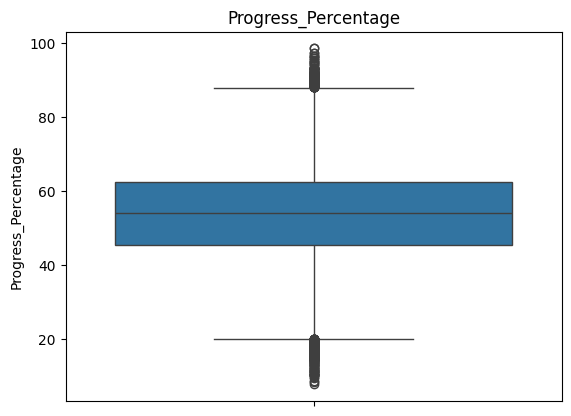

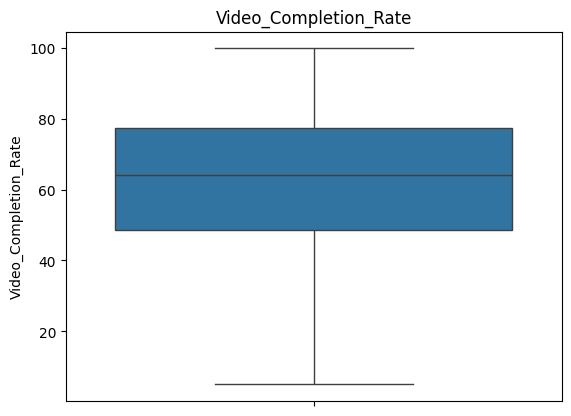

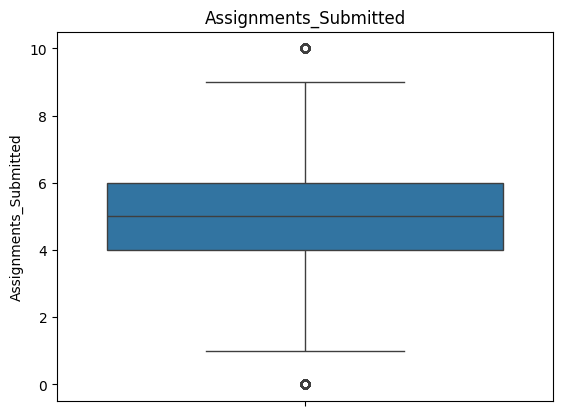

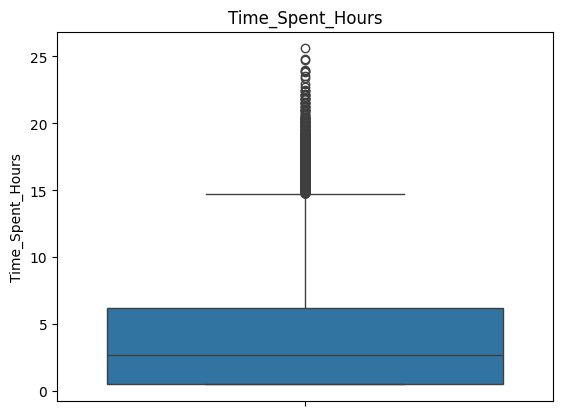

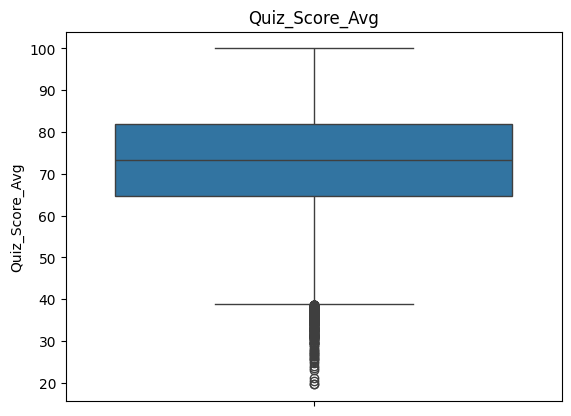

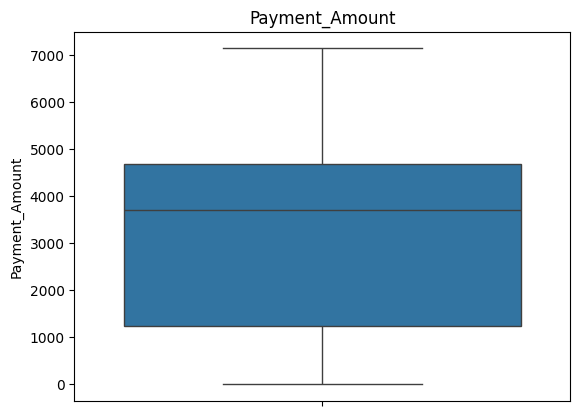

In [ ]:
for i in X.select_dtypes("number").columns:
  sns.boxplot(X[i])
  plt.title(i)
  plt.show()

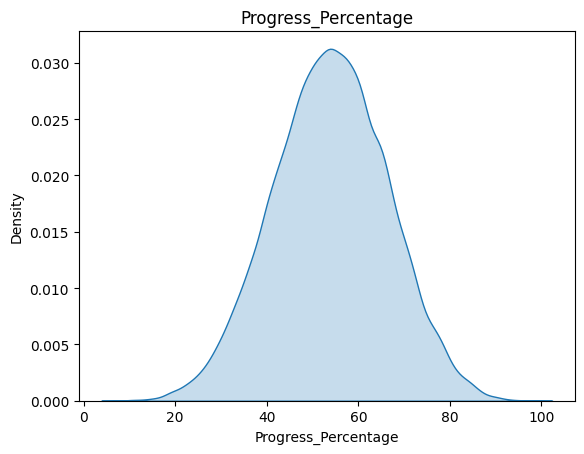

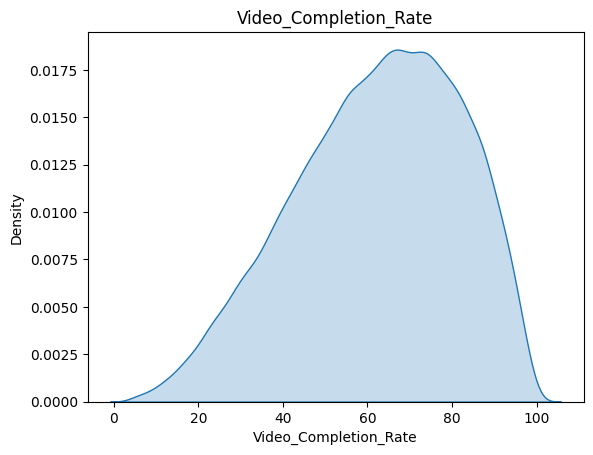

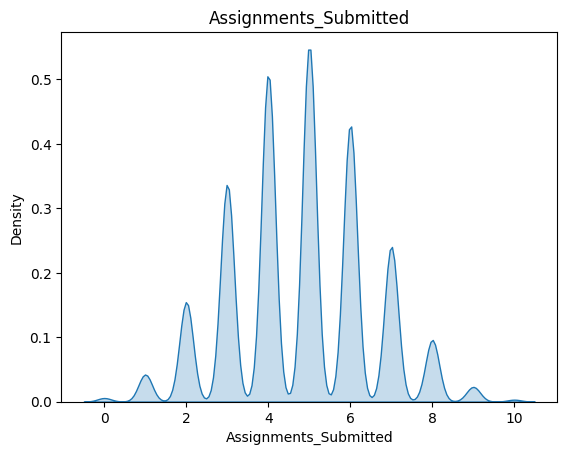

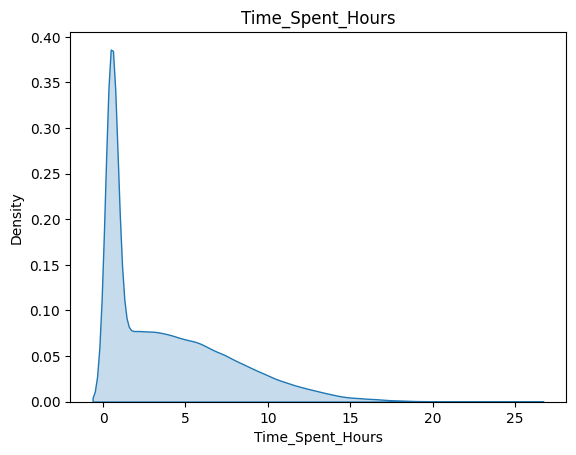

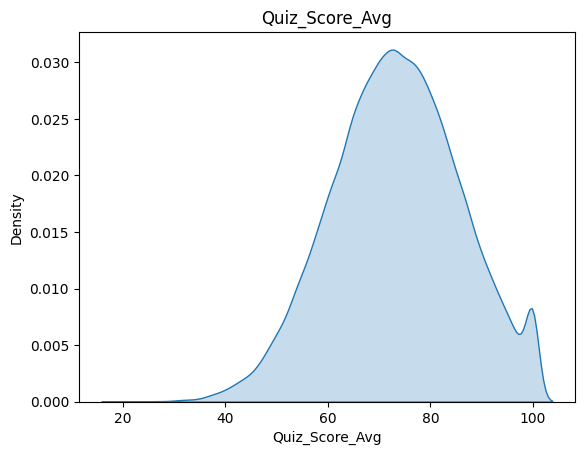

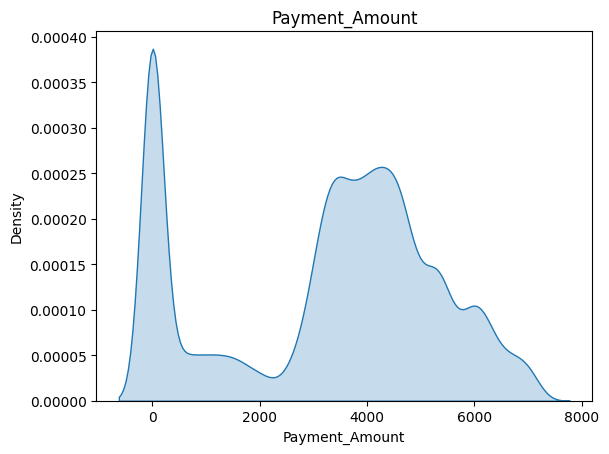

In [ ]:
for i in X.select_dtypes("number"):
  sns.kdeplot(X[i],fill=True)
  plt.title(i)
  plt.show()

Splitting

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=40,stratify=y)

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(80000, 13)
(20000, 13)
(80000,)
(20000,)


In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 80000 entries, 28993 to 83325
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Progress_Percentage          80000 non-null  float64
 1   Video_Completion_Rate        80000 non-null  float64
 2   Assignments_Submitted        80000 non-null  int64  
 3   Time_Spent_Hours             80000 non-null  float64
 4   Quiz_Score_Avg               80000 non-null  float64
 5   Payment_Amount               80000 non-null  int64  
 6   Payment_Mode                 80000 non-null  object 
 7   Fee_Paid                     80000 non-null  object 
 8   Internet_Connection_Quality  80000 non-null  object 
 9   Employment_Status            80000 non-null  object 
 10  Device_Type                  80000 non-null  object 
 11  Education_Level              80000 non-null  object 
 12  Gender                       80000 non-null  object 
dtypes: float64(4), in

In [ ]:
y_train

,target_encoded
46630,1
94689,0
63232,1
56486,0
65811,1
...,...
56760,1
93176,0
80037,1
30727,1


Data Preprocessing

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder,RobustScaler
Transformers=ColumnTransformer(transformers=[
    ("cat",OrdinalEncoder(),[6,7,8,9,10,11,12]),
    ("num",RobustScaler(),[0,1,2,3,4,5])
                                         ],remainder="passthrough")
X_train_trans=Transformers.fit_transform(X_train)
X_test_trans=Transformers.transform(X_test)

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline


pipeline=Pipeline(steps=[("preprocess",Transformers),("model",DecisionTreeClassifier(random_state=42))])

param_dist={'model__min_samples_split': np.arange(2, 21),
'model__min_samples_leaf': np.arange(1, 21),
'model__max_depth': np.arange(1, 51),
 'model__criterion': ['gini', 'entropy']}

random_search=RandomizedSearchCV(estimator=pipeline,param_distributions=param_dist,cv=6)

In [ ]:
random_search.fit(X_train,y_train)

RandomizedSearchCV(cv=6,
                   estimator=Pipeline(steps=[('preprocess',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('cat',
                                                                               OrdinalEncoder(),
                                                                               [6,
                                                                                7,
                                                                                8,
                                                                                9,
                                                                                10,
                                                                                11,
                                                                                12]),
                                                                              ('num',
                                                                               RobustScaler(),
                                                                               [0,
                                                                                1,
                                                                                2,
                                                                                3,
                                                                                4,
                                                                                5])])),
                                             ('model',
                                              DecisionTreeClassifier(random_state=42))]),
                   param_distributions={'model__criterion': ['gini', 'entropy'],
                                        'model__max_depth': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50]),
                                        'model__min_samples_leaf': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20]),
                                        'model__min_samples_split': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19, 20])})

In [ ]:
random_search.best_params_

{'model__min_samples_split': np.int64(11),
 'model__min_samples_leaf': np.int64(3),
 'model__max_depth': np.int64(3),
 'model__criterion': 'entropy'}

Evaluation

In [ ]:
y_predict = random_search.predict(X_test)
ac_score = accuracy_score(y_predict, y_test)
ac_score

0.59445

In [ ]:
y_train_predict=random_search.predict(X_train)
ac_score=accuracy_score(y_train_predict,y_train)
ac_score

0.5916

Model

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

dt_pipeline = Pipeline(steps=[
    ("preprocess", Transformers),
    ("model", DecisionTreeClassifier(
        criterion='entropy',
        max_depth=3,
        min_samples_split=11,
        min_samples_leaf=3,
        random_state=42
    ))
])

In [ ]:
dt_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat', OrdinalEncoder(),
                                                  [6, 7, 8, 9, 10, 11, 12]),
                                                 ('num', RobustScaler(),
                                                  [0, 1, 2, 3, 4, 5])])),
                ('model',
                 DecisionTreeClassifier(criterion='entropy', max_depth=3,
                                        min_samples_leaf=3,
                                        min_samples_split=11,
                                        random_state=42))])

In [ ]:
y_pred = dt_pipeline.predict(X_test)
ac_score = accuracy_score(y_pred, y_test)
ac_score

0.59445

In [ ]:
y_train_predict = dt_pipeline.predict(X_train)
ac_score = accuracy_score(y_train_predict, y_train)
ac_score

0.5916

DT giving the fit as train=59 and test=59

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report of Dt:")
print("Classification Report :\n",classification_report(y_test, y_pred))

Accuracy: 0.59445

Classification Report of Dt:
              precision    recall  f1-score   support

           0       0.59      0.66      0.62     10194
           1       0.60      0.52      0.56      9806

    accuracy                           0.59     20000
   macro avg       0.60      0.59      0.59     20000
weighted avg       0.59      0.59      0.59     20000



Pickled model

In [ ]:
import pickle

best_students_dt = random_search.best_estimator_

with open("best_students_dtree.pkl", "wb") as f:
    pickle.dump(dt_pipeline, f)

In [ ]:
import pickle

best_students_dt = random_search.best_estimator_

with open("best_students_dtree.pkl", "wb") as f:
    pickle.dump(best_students_dt, f)

KNN

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier


pipeline=Pipeline(steps=[("preprocess",Transformers),("model",KNeighborsClassifier())])
# Define parameter distributions for RandomizedSearchCV with corrected parameter names
param_dist={'model__n_neighbors': np.arange(1, 51),
 'model__metric':['manhattan','euclidean','minkowski','cosine']}


knn_random_searchcv=RandomizedSearchCV(pipeline,param_distributions=param_dist)

In [ ]:
knn_random_searchcv.fit(X_train,y_train)

RandomizedSearchCV(estimator=Pipeline(steps=[('preprocess',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('cat',
                                                                               OrdinalEncoder(),
                                                                               [6,
                                                                                7,
                                                                                8,
                                                                                9,
                                                                                10,
                                                                                11,
                                                                                12]),
                                                                              ('num',
                                                                               RobustScaler(),
                                                                               [0,
                                                                                1,
                                                                                2,
                                                                                3,
                                                                                4,
                                                                                5])])),
                                             ('model',
                                              KNeighborsClassifier())]),
                   param_distributions={'model__metric': ['manhattan',
                                                          'euclidean',
                                                          'minkowski',
                                                          'cosine'],
                                        'model__n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50])})

In [ ]:
knn_y_test=knn_random_searchcv.predict(X_test)
knn_y_testscore=accuracy_score(knn_y_test,y_test)
knn_y_testscore

0.58835

In [ ]:
knn_y_train=knn_random_searchcv.predict(X_train)
knn_y_trainscore=accuracy_score(knn_y_train,y_train)
knn_y_trainscore

0.619875

KNN is Slightly Over fitted as the train=61 and test =58

# Logistic

In [ ]:
from sklearn.linear_model import LogisticRegression
log_pipeline = Pipeline(steps=[
    ("preprocess", Transformers),
    ("model", LogisticRegression(max_iter=200))
])

param_dist = {
    "model__penalty": ["l1", "l2"],
    "model__C": np.logspace(-3,3,20),
    "model__solver": ["liblinear"]
}

log_random_search = RandomizedSearchCV(
    estimator=log_pipeline,
    param_distributions=param_dist,
    random_state=42
)
log_random_search.fit(X_train,y_train)

RandomizedSearchCV(estimator=Pipeline(steps=[('preprocess',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('cat',
                                                                               OrdinalEncoder(),
                                                                               [6,
                                                                                7,
                                                                                8,
                                                                                9,
                                                                                10,
                                                                                11,
                                                                                12]),
                                                                              ('num',
                                                                               RobustScaler(),
                                                                               [0,
                                                                                1,
                                                                                2,
                                                                                3,
                                                                                4,
                                                                                5])])),
                                             ('model',
                                              LogisticRegression(max_iter=200))]),
                   param_distributions={'model__C': array([1.00000000e-03, 2.06913808e-03, 4.28133240e-03, 8.85866790e-03,
       1.83298071e-02, 3.79269019e-02, 7.84759970e-02, 1.62377674e-01,
       3.35981829e-01, 6.95192796e-01, 1.43844989e+00, 2.97635144e+00,
       6.15848211e+00, 1.27427499e+01, 2.63665090e+01, 5.45559478e+01,
       1.12883789e+02, 2.33572147e+02, 4.83293024e+02, 1.00000000e+03]),
                                        'model__penalty': ['l1', 'l2'],
                                        'model__solver': ['liblinear']},
                   random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score
print("Logisctic Regression of Train Data :",accuracy_score(y_train, log_random_search.predict(X_train)))
print("Logisctic Regression of Test Data :",accuracy_score(y_test, log_random_search.predict(X_test)))

Logisctic Regression of Train Data : 0.60605
Logisctic Regression of Test Data : 0.6064


In [ ]:
print("Classification Report of Logistic:\n",classification_report(y_test,log_random_search.predict(X_test)))

Classification Report of Logistic:
               precision    recall  f1-score   support

           0       0.61      0.61      0.61     10194
           1       0.60      0.60      0.60      9806

    accuracy                           0.61     20000
   macro avg       0.61      0.61      0.61     20000
weighted avg       0.61      0.61      0.61     20000



Ensembles

In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
clf1=KNeighborsClassifier()
clf2=DecisionTreeClassifier()
clf3=SVC(probability=True)
clf4=LogisticRegression()
voting_clf=VotingClassifier(estimators=[("knn",clf1),
                                        ("dt",clf2),
                                        ("svc",clf3),
                                        ("lr",clf4)],
                            voting="soft")
voting_clf.fit(X_train_trans,y_train)

VotingClassifier(estimators=[('knn', KNeighborsClassifier()),
                             ('dt', DecisionTreeClassifier()),
                             ('svc', SVC(probability=True)),
                             ('lr', LogisticRegression())],
                 voting='soft')

In [ ]:
print("Accuracy with ensemble using Voting Classifier on Test data :",accuracy_score(y_test,(voting_clf.predict(X_test_trans))))
print("Accuracy with ensemble using Voting Classifier on Train data :",accuracy_score(y_train,(voting_clf.predict(X_train_trans))))

Accuracy with ensemble using Voting Classifier on Test data : 0.55695
Accuracy with ensemble using Voting Classifier on Train data : 0.960825


Accuracy with ensemble using Voting Classifier on Test data : 0.55695

Accuracy with ensemble using Voting Classifier on Train data : 0.960825

Stacking Ensemble


In [ ]:
from sklearn.ensemble import StackingClassifier
base_learners=[("knn",clf1),("dt",clf2),("svc",clf3)]
mini_model=clf4 # Changed from ("lr",clf4) to clf4
stak_clf=StackingClassifier(estimators=base_learners,
                            final_estimator=mini_model,
                            cv=5)
stak_clf.fit(X_train_trans,y_train)

StackingClassifier(cv=5,
                   estimators=[('knn', KNeighborsClassifier()),
                               ('dt', DecisionTreeClassifier()),
                               ('svc', SVC())],
                   final_estimator=LogisticRegression())

In [ ]:
print("Accuracy with ensemble using Stacking Classifier on Test data :",accuracy_score(y_test,(stak_clf.predict(X_test_trans))))
print("Accuracy with ensemble using Stacking Classifier on Train data :",accuracy_score(y_train,(stak_clf.predict(X_train_trans))))

BOOSTINg

Adaboosting

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

ada_pipeline = Pipeline([
    ("preprocess", Transformers),
    ("model", AdaBoostClassifier())
])

param_dist_ada = {
    "model__n_estimators":[50,100,200,300],
    "model__learning_rate":[0.01,0.1,0.5,1],
    "model__estimator":[
        DecisionTreeClassifier(max_depth=1)
    ]
}
ada_search = RandomizedSearchCV(
    estimator=ada_pipeline,
    param_distributions=param_dist_ada,
    cv=5,
    random_state=42
)

ada_search.fit(X_train,y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocess',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('cat',
                                                                               OrdinalEncoder(),
                                                                               [6,
                                                                                7,
                                                                                8,
                                                                                9,
                                                                                10,
                                                                                11,
                                                                                12]),
                                                                              ('num',
                                                                               RobustScaler(),
                                                                               [0,
                                                                                1,
                                                                                2,
                                                                                3,
                                                                                4,
                                                                                5])])),
                                             ('model', AdaBoostClassifier())]),
                   param_distributions={'model__estimator': [DecisionTreeClassifier(max_depth=1)],
                                        'model__learning_rate': [0.01, 0.1, 0.5,
                                                                 1],
                                        'model__n_estimators': [50, 100, 200,
                                                                300]},
                   random_state=42)

In [ ]:
print("Accuracy with ensemble using Adaboosting Classifier on Test data :",accuracy_score(y_test,(ada_search.predict(X_test))))
print("Accuracy with ensemble using Adaboosting Classifier on Train data :",accuracy_score(y_train,(ada_search.predict(X_train))))


Accuracy with ensemble using Adaboosting Classifier on Test data : 0.60515
Accuracy with ensemble using Adaboosting Classifier on Train data : 0.6043


In [ ]:
print("classification report of Adaboosting:\n",classification_report(y_test,ada_search.predict(X_test)))

classification report of Adaboosting:
               precision    recall  f1-score   support

           0       0.61      0.61      0.61     10194
           1       0.60      0.60      0.60      9806

    accuracy                           0.61     20000
   macro avg       0.60      0.60      0.60     20000
weighted avg       0.61      0.61      0.61     20000



Adaboosting also train=60 and test =60


Bagging
Randomforest

In [ ]:
from sklearn.ensemble import RandomForestClassifier


rf_pipeline = Pipeline([
    ("preprocess", Transformers),
    ("model", RandomForestClassifier(random_state=42))
])

param_dist_rf = {
    "model__n_estimators": [50,100,150],
    "model__max_depth": [5,10,20],
    }
rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_dist_rf,cv=5,
    random_state=42
)

rf_search.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocess',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('cat',
                                                                               OrdinalEncoder(),
                                                                               [6,
                                                                                7,
                                                                                8,
                                                                                9,
                                                                                10,
                                                                                11,
                                                                                12]),
                                                                              ('num',
                                                                               RobustScaler(),
                                                                               [0,
                                                                                1,
                                                                                2,
                                                                                3,
                                                                                4,
                                                                                5])])),
                                             ('model',
                                              RandomForestClassifier(random_state=42))]),
                   param_distributions={'model__max_depth': [5, 10, 20],
                                        'model__n_estimators': [50, 100, 150]},
                   random_state=42)

In [ ]:
print(" Randomforest on Test data :",accuracy_score(y_test,(rf_search.predict(X_test))))
print(" Randomforest on Train data :",accuracy_score(y_train,(rf_search.predict(X_train))))

 Randomforest on Test data : 0.603
 Randomforest on Train data : 0.650775


Random forest is overfitted with train =65 and test =60


Gradient Boosting

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier


gb_clf=GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42

)
gb_clf.fit(X_train_trans,y_train)
print(f"Train data accuracy using GradientBoost Classifier :{accuracy_score(gb_clf.predict(X_train_trans),y_train)}")
print(f"Test data accuracy using GradientBoost Classifier :{accuracy_score(gb_clf.predict(X_test_trans),y_test)}")
print("\nClassifiaction Report of Gradientboost:\n",classification_report(y_test,gb_clf.predict(X_test_trans)))

Train data accuracy using GradientBoost Classifier :0.610425
Test data accuracy using GradientBoost Classifier :0.6014

Classifiaction Report of Gradientboost:
               precision    recall  f1-score   support

           0       0.61      0.61      0.61     10194
           1       0.59      0.59      0.59      9806

    accuracy                           0.60     20000
   macro avg       0.60      0.60      0.60     20000
weighted avg       0.60      0.60      0.60     20000



Train data accuracy using GradientBoost Classifier :0.610425

Test data accuracy using GradientBoost Classifier :0.6014

XGBOOSTING

In [ ]:
import xgboost as xgb
from sklearn.metrics import classification_report

xgb_model=xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric='logloss',
    max_depth=8,
    learning_rate=0.1,
    n_estimators=100

)

xgb_model.fit(X_train_trans,y_train)
y_pred_xgb_test=xgb_model.predict(X_test_trans)
y_pred_xgb_train=xgb_model.predict(X_train_trans)

# Accuracy
print(f"Accuracy for XGBoost Train: {accuracy_score(y_train,y_pred_xgb_train):.2f}")
print(f"Accuracy for XGBoost Test: {accuracy_score(y_test,y_pred_xgb_test):.2f}")
print(f"\n Classification Report for XGBoost:\n {classification_report(y_test,y_pred_xgb_test)}")

Accuracy for XGBoost Train: 0.69
Accuracy for XGBoost Test: 0.60

 Classification Report for XGBoost:
               precision    recall  f1-score   support

           0       0.60      0.61      0.61     10194
           1       0.59      0.58      0.59      9806

    accuracy                           0.60     20000
   macro avg       0.60      0.60      0.60     20000
weighted avg       0.60      0.60      0.60     20000



In [ ]:
print(f"\n Classification Report for XGBoost:\n {classification_report(y_test,y_pred_xgb_test)}")
print("\nClassifiaction Report of Gradientboost:\n",classification_report(y_test,gb_clf.predict(X_test_trans)))
print("classification report of Adaboosting:\n",classification_report(y_test,ada_search.predict(X_test)))
print("Classification Report of Logistic:\n",classification_report(y_test,log_random_search.predict(X_test)))
print("Classification Report of DT:\n",classification_report(y_test, y_pred))




 Classification Report for XGBoost:
               precision    recall  f1-score   support

           0       0.60      0.61      0.61     10194
           1       0.59      0.58      0.59      9806

    accuracy                           0.60     20000
   macro avg       0.60      0.60      0.60     20000
weighted avg       0.60      0.60      0.60     20000


Classifiaction Report of Gradientboost:
               precision    recall  f1-score   support

           0       0.61      0.61      0.61     10194
           1       0.59      0.59      0.59      9806

    accuracy                           0.60     20000
   macro avg       0.60      0.60      0.60     20000
weighted avg       0.60      0.60      0.60     20000

classification report of Adaboosting:
               precision    recall  f1-score   support

           0       0.61      0.61      0.61     10194
           1       0.60      0.60      0.60      9806

    accuracy                           0.61     20000
   macro 